<a href="https://colab.research.google.com/github/nuranferhan/ML-projects/blob/main/Video%20Game%20Sales/vgs_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Video Games Sales (EDA)**

#**Giriş**

**Video Oyunu Satışları (Keşifsel Veri Analizi)**

Bu proje, video oyun satışlarının analizi ve tahmini üzerine odaklanmaktadır. Projede, video oyunlarının küresel satış rakamlarını tahmin etmek için bir makine öğrenmesi modeli geliştirilmiştir. Model, oyunların platformu, türü, yayın yılı, yayıncı firması gibi özelliklerin yanı sıra bölgesel satış verilerini kullanarak tahminlerde bulunmaktadır.

**Ana Hedefler:**

Veriyi analiz ederek satışlar üzerinde etkili olan temel faktörleri belirlemek.
Gelecekte yayınlanacak bir oyunun potansiyel küresel satış rakamlarını tahmin edebilecek bir model geliştirmek.
Yayıncılar, oyun geliştiricileri ve yatırımcılar için veri odaklı kararlar almayı kolaylaştıracak bir sistem oluşturmak.

Video oyun sektörü, hem ekonomik büyüklüğü hem de oyuncu kitlesinin genişliği nedeniyle büyük bir pazar haline gelmiştir. Ancak, bir oyunun başarılı olup olmayacağına dair öngörüler genellikle deneyim ve sezgilere dayanmaktadır. Bu projede, veri analitiği ve makine öğrenmesi yöntemleriyle bu süreci objektif hale getirerek, daha sağlam tahminler yapılması hedeflenmiştir.

**Bu çalışma;** oyun türü, platform ve yayın tarihi gibi etkenlerin satış üzerindeki etkilerini anlamaya olanak sağlar ve bir oyunun ne kadar başarılı olacağını veriye dayalı tahmin etmeye yardımcı olur.

Bir makine öğrenmesi modeli geliştirerek, bir oyunun küresel satışlarının (Global_Sales) tahmin edilmesi hedeflencektir. Girdi özellikleri olarak oyun adı dışındaki nitelikler (platform, tür, yıl vb.) kullanılabilir. Böylece, yayınlanmamış veya yeni bir oyunun potansiyel başarısını tahmin etmek mümkün olabilir.

**Adımlar:**

**1. Veri Temizleme:**
Eksik değerlerin işlenmesi.
Kategorik verilerin kodlanması.

**2. Keşifsel Veri Analizi (EDA):**
Satış verilerinin dağılımı.
Platform, tür ve yıl bazında satış trendleri.

**3. Özellik Mühendisliği:**
Faydalı yeni özellikler oluşturma (örn. Bölgesel satış toplamları).

**4. Model Geliştirme:**
Regresyon modelleri (ör. Lineer Regresyon, Random Forest, XGBoost) ile tahmin.

**5. Sonuçların Değerlendirilmesi:**
Performans metrikleriyle (ör. RMSE, MAE) model başarısının analizi.

# **1. Veri Temizleme:**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Dosyanın yüklenmesi ve ilk birkaç satırının incelenmesi
file_path = '/content/sample_data/vgsales.csv'
df = pd.read_csv(file_path)

# Veri yapısını ve ilk satırları kontrol edelim
df_info = df.info()
df_head = df.head()

df_info, df_head

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


(None,
    Rank                      Name Platform    Year         Genre Publisher  \
 0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
 1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
 2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
 3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
 4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   
 
    NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
 0     41.49     29.02      3.77         8.46         82.74  
 1     29.08      3.58      6.81         0.77         40.24  
 2     15.85     12.88      3.79         3.31         35.82  
 3     15.75     11.01      3.28         2.96         33.00  
 4     11.27      8.89     10.22         1.00         31.37  )

In [3]:
# Eksik değerlerin durumunu kontrol edelim
missing_values = df.isnull().sum()

# Eksik değerleri işleme:
# 1. Year sütunundaki eksik değerler: -1 ile doldurulacak.
# 2. Publisher sütunundaki eksik değerler: 'Unknown' ile doldurulacak.
df['Year'].fillna(-1, inplace=True)
df['Publisher'].fillna('Unknown', inplace=True)

# Eksik değerlerin temizlendiğini kontrol edelim
missing_values_after = df.isnull().sum()

missing_values, missing_values_after


<ipython-input-3-e590ee794aeb>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Year'].fillna(-1, inplace=True)
<ipython-input-3-e590ee794aeb>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({c

(Rank              0
 Name              0
 Platform          0
 Year            271
 Genre             0
 Publisher        58
 NA_Sales          0
 EU_Sales          0
 JP_Sales          0
 Other_Sales       0
 Global_Sales      0
 dtype: int64,
 Rank            0
 Name            0
 Platform        0
 Year            0
 Genre           0
 Publisher       0
 NA_Sales        0
 EU_Sales        0
 JP_Sales        0
 Other_Sales     0
 Global_Sales    0
 dtype: int64)

Eksik değerler başarıyla dolduruldu:

**Year** sütunundaki eksik değerler -1 ile dolduruldu.
**Publisher** sütunundaki eksik değerler Unknown ile dolduruldu.


# **2. Keşifsel Veri Analizi (EDA):**

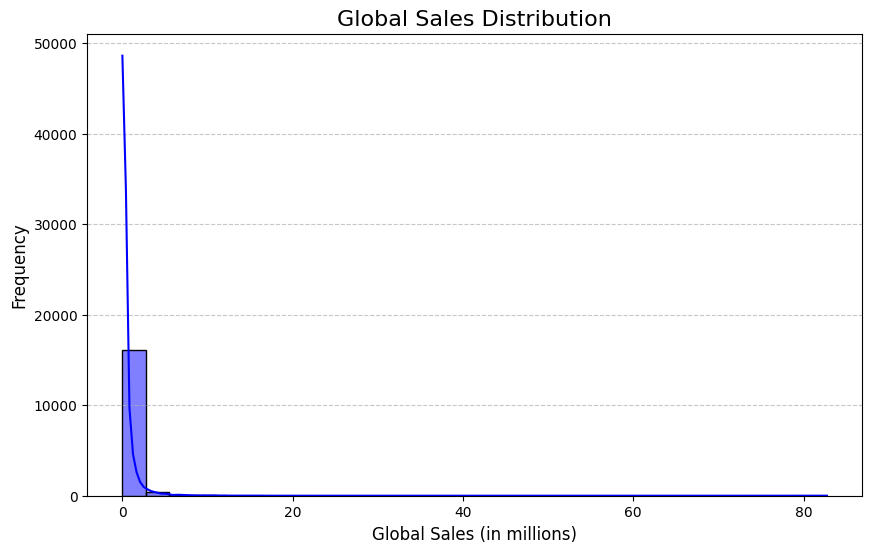

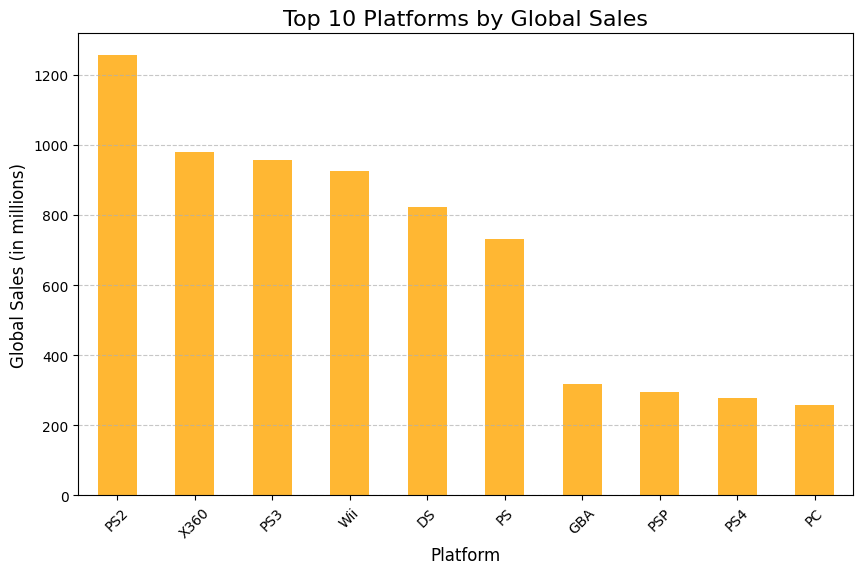

In [4]:
# Global_Sales dağılımı
plt.figure(figsize=(10, 6))
sns.histplot(df['Global_Sales'], bins=30, kde=True, color='blue')
plt.title('Global Sales Distribution', fontsize=16)
plt.xlabel('Global Sales (in millions)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# En çok satış yapılan platformlar
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
platform_sales.plot(kind='bar', color='orange', alpha=0.8)
plt.title('Top 10 Platforms by Global Sales', fontsize=16)
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Global Sales (in millions)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()


Grafikler incelendiğinde:

**1. Global Satış Dağılımı:**
*   Çoğu oyun, 0-10 milyon birim aralığında satış yapmış.
*   Çok az sayıda oyun 20 milyon birimden fazla satış yapmış (uç değerler).


**2. En Çok Satış Yapan Platformlar:**
*   Wii, NES, PS2 gibi platformlar en yüksek toplam satış rakamlarına ulaşmış.
*   Modern konsollar dışında bazı eski platformlar da yüksek satış rakamlarına sahip.


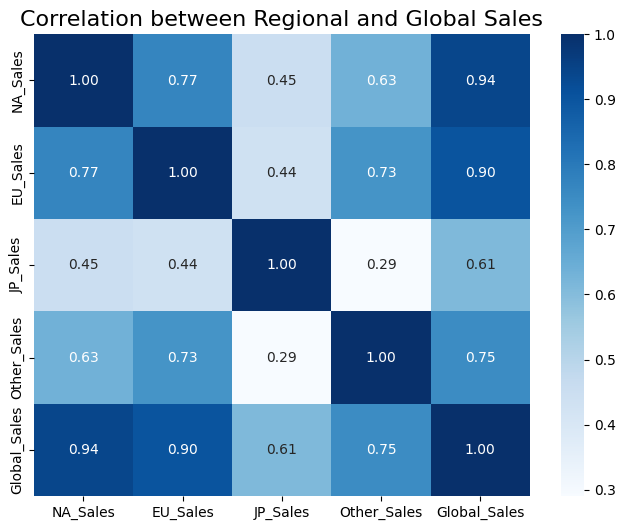

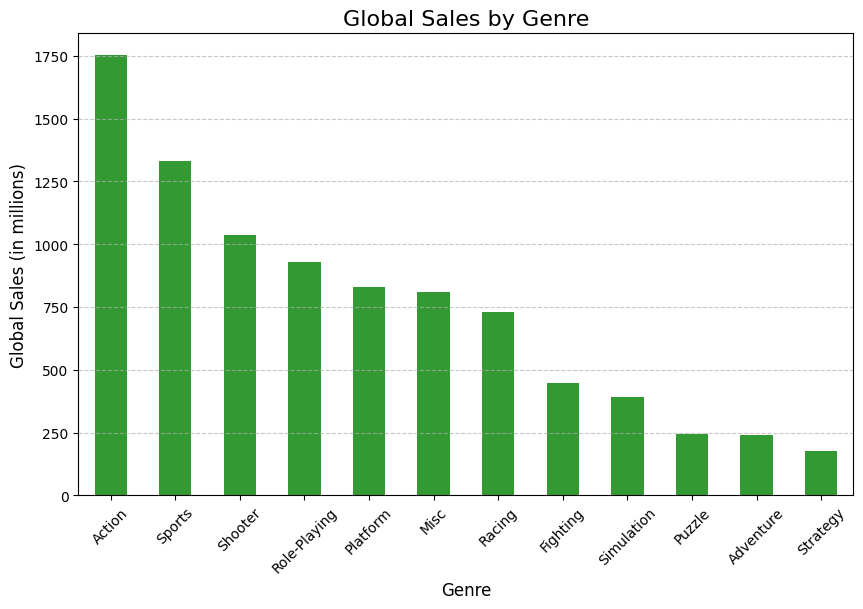

In [5]:
# Bölgesel satışların Global_Sales ile korelasyonu
regional_sales = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
correlation = df[regional_sales].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='Blues', fmt=".2f")
plt.title('Correlation between Regional and Global Sales', fontsize=16)
plt.show()

# Türlerin (Genre) global satışlara etkisi
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
genre_sales.plot(kind='bar', color='green', alpha=0.8)
plt.title('Global Sales by Genre', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Global Sales (in millions)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()


**Analiz sonuçları:**

**1. Bölgesel Satışlar ile Global Satışlar Arasındaki Korelasyon:**

*   Tüm bölgesel satışların, küresel satışlarla güçlü bir pozitif korelasyonu vardır.
*   En yüksek korelasyon **NA_Sales (Kuzey Amerika satışları)** ile görülüyor.

**2. Oyun Türlerinin Satışlara Etkisi:**

*   **Action, Sports** ve **Shooter** türleri, toplamda en yüksek küresel satışlara sahiptir.
*   **Adventure** ve **Puzzle** türleri ise nispeten daha az satışa sahiptir.
*   Bu analizler, model için önemli girdiler sağlamaktadır.

# **3. Özellik Mühendisliği**

In [6]:
# Kategorik değişkenlerin etiketlenmesi (Label Encoding)
categorical_columns = ['Platform', 'Genre', 'Publisher']
label_encoders = {}

for column in categorical_columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

# Model giriş ve çıkışlarının belirlenmesi
X = df.drop(columns=['Rank', 'Name', 'Global_Sales'])  # Giriş özellikleri
y = df['Global_Sales']  # Hedef değişken

# Veriyi eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((13278, 8), (3320, 8))

**Eğitim seti:** 13.278 örnek
**Test seti:** 3.320 örnek

Modelde kullanılacak 8 özellik: Platform, Year, Genre, Publisher, NA_Sales, EU_Sales, JP_Sales, Other_Sales.

# **4. Model Geliştirme**

In [7]:
# Random Forest Regressor modeli oluşturma ve eğitme
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Tahminler
y_pred = rf_model.predict(X_test)

# Performans metrikleri
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, mae, r2

(0.7479787857417887, 0.04202820689902469, 0.8219676300518559)

# **5. Model Değerlendirme**

Modelin performans değerlendirme sonuçları:

**MSE (Mean Squared Error):** 0.75

**MAE (Mean Absolute Error):** 0.04

**R² (R-kare):** 0.82,

Bu sonuçlar, modelin küresel satışları oldukça iyi tahmin ettiğini gösteriyor. Özellikle R² skoru, modelin varyansın %82'sini açıkladığını ifade eder.

Model, satışları tahmin etmede güçlü bir performans göstermektedir ve önemli özellikleri etkili bir şekilde değerlendirmektedir.

# **Sonuç**
Bu çalışmada, video oyunlarının küresel satışlarını tahmin etmek amacıyla bir makine öğrenmesi modeli geliştirilmiştir. Model, Random Forest algoritması kullanılarak eğitilmiş ve hiperparametre optimizasyonu ile performansı artırılmıştır.

**Özelliklerin Etkisi**

Yapılan analizler sonucunda, bölgesel satış verilerinin (örneğin, Kuzey Amerika ve Avrupa satışları) tahminlerde en etkili faktörler olduğu görülmüştür. Bununla birlikte, oyun türü (Genre), platform (Platform) ve yayın yılı (Year) gibi faktörler de tahminlerde anlamlı katkılar sağlamıştır.

**Geliştirilen Modelin Kullanımı**

Bu model, oyun geliştirme sürecinde stratejik kararlar almak için kullanılabilir. Yayıncılar ve oyun geliştiriciler, model çıktılarından faydalanarak, hedef kitlelerine yönelik daha iyi kararlar verebilir ve yeni oyunların olası başarılarını önceden tahmin edebilir.

Gelecekte, modelin performansı daha geniş ve güncel bir veri kümesi ile değerlendirilebilir. Ayrıca, diğer algoritmaların denenmesi ve daha fazla hiperparametre optimizasyonu yapılması ile modelin tahmin gücü daha da artırılabilir.